In [1]:
import openmc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec # makes plot pretty for oneNote
import pandas as pd
import os
import openmc.deplete as dep
#import openmc_data_downloader as odd
from PIL import Image
from collections import defaultdict #To use dictionaries to remove dublicates

date = '171225'
number_of_files = -1

In [2]:
def set_mat(name):
    materials = openmc.Materials.from_xml('materials.xml')
    fuel_mat = None
    water = None
    heavy_water = None
    blanket_CA = None
    for mat in materials:
        print(mat.name)
        if mat.name==name:
            fuel_mat = mat
        elif mat.name=="h2o":
            water = mat
        elif mat.name=="d2o":
            heavy_water = mat
        elif mat.name=="Blanket CA":
            blanket_CA = mat
        
    return fuel_mat, heavy_water, water, blanket_CA
#print(materials)
fuel_material, heavy_water, water, blanket_CA = set_mat("Fuel CA")
print(fuel_material)
print(blanket_CA)

uo2
h2o
d2o
Fuel CA
Blanket CA
Fuel A
Fuel B
Fuel C
Material
	ID             =	7
	Name           =	Fuel CA
	Temperature    =	None
	Density        =	43.83576337924426 [g/cm3]
	Volume         =	None [cm^3]
	Depletable     =	True
	S(a,b) Tables  
	Nuclides       
	Li6            =	3.6500000000239107e-06 [ao]
	Li7            =	0.3649963499999999 [ao]
	F19            =	0.5809999999999998 [ao]
	U234           =	2.059926688005198e-05 [ao]
	U235           =	0.0023046478462013975 [ao]
	U238           =	0.043664196492823694 [ao]
	U236           =	1.0556394094843727e-05 [ao]
	Th230          =	1.6000000000000004e-06 [ao]
	Th232          =	0.007998400000000003 [ao]

Material
	ID             =	8
	Name           =	Blanket CA
	Temperature    =	None
	Density        =	45.76501020921229 [g/cm3]
	Volume         =	None [cm^3]
	Depletable     =	True
	S(a,b) Tables  
	Nuclides       
	Li6            =	0.026561499999999995 [ao]
	Li7            =	0.3234384999999999 [ao]
	F19            =	0.59         [ao]
	Th2

In [4]:
#Geometry
moderator_cell = None
fuel_cell = None
def set_geom_fuel_shell(water_or,sphere_or,sphere_ir,with_blanket=False,blanket_or=0):
    #
    
    global moderator_cell, fuel_cell
    eps=0.0001 # constant to make sure geomitries dont overlap
    os.system("rm geometry.xml")
    fuel_or = openmc.Sphere(r=sphere_or) #fuel cylinder with outer radius
    fuel_ir = openmc.Sphere(r=sphere_ir) #fuel cylinder with outer radius
    fuel_region = +fuel_ir & -fuel_or    #inside the fuel fuel
    fuel_cell = openmc.Cell(1, 'fuel')
    fuel_cell.fill = fuel_material
    fuel_cell.region = fuel_region

    #Define moderator area
    water_inner_sphere= openmc.Sphere(r=sphere_ir)
    water_middle_sphere= openmc.Sphere(r=sphere_or)
    water_outer_sphere= openmc.Sphere(r=water_or)
    water_region1 = -water_inner_sphere
    water_region2 = +water_middle_sphere & -water_outer_sphere

    moderator_cell = openmc.Cell(2,'moderator')
    moderator_cell.fill = heavy_water
    moderator_cell.region = water_region1 | water_region2
    
    #If blanket is a part of the geometry
    if with_blanket:
        blanket_outer_sphere = openmc.Sphere(r=blanket_or)
        blanket_region = +water_outer_sphere & -blanket_outer_sphere
        blanket_cell = openmc.Cell(3,'blanket')
        blanket_cell.region = blanket_region
        blanket_cell.fill = blanket_CA

        boundary = openmc.Sphere(r=blanket_or+eps,boundary_type='reflective')
        outer_cell = openmc.Cell(4,region=+blanket_outer_sphere & -boundary) 
            #Outer_cell is only to sepeate the boundary a bit from the geometry
        root = openmc.Universe(cells=[fuel_cell, moderator_cell,blanket_cell,outer_cell])
    
    else:
        #we define boundary condition
        boundary = openmc.Sphere(r = water_or+eps, boundary_type='reflective')
        outer_cell = openmc.Cell(4,region = +water_outer_sphere & -boundary)
        root = openmc.Universe(cells=[fuel_cell, moderator_cell,outer_cell])
    

    geom = openmc.Geometry()
    geom.root_universe = root
    geom.export_to_xml()


    return root, fuel_cell, moderator_cell



#main_u = sphere(sphere_r=100) #radius in cm
geom_size=12
geom_or=11
geom_ir=10
main_u,fuel,moderator = set_geom_fuel_shell(water_or=geom_size,sphere_or=geom_or,sphere_ir=geom_ir)

In [5]:
# Stochastic Volume Calculations
print(fuel_cell)
def stochastic_vol_calc(fuel_cell,geom_or):
    settings_vol = openmc.Settings()
    
    geom = openmc.Geometry.from_xml("geometry.xml")
    mat = openmc.Materials.from_xml("materials.xml")
    vol_model = openmc.Model(geometry=geom, materials=mat, settings=settings_vol)
    
    lower_left = (-geom_or,-geom_or,-geom_or)
    upper_right = (geom_or,geom_or,geom_or)
    fuel_vol_calc = openmc.VolumeCalculation([fuel_cell],int(1e7),lower_left, upper_right) #max # of points 1e8 before slow calc
    
    #Trigger to stop vol_calc if it is precise enough before number of sambling points 
    #makes calculation slow for some reason
    fuel_vol_calc.set_trigger(1e-3, 'rel_err')  
    settings.run_mode = 'volume'
    settings_vol.volume_calculations = [fuel_vol_calc]
    
    vol_model.calculate_volumes()
def shell_vol_calc(geom_or,geom_ir):
    volume=4/3*np.pi*(geom_or**3-geom_ir**3)
    return volume

Cell
	ID             =	1
	Name           =	fuel
	Fill           =	Material 7
	Region         =	(2 -1)
	Rotation       =	None
	Temperature    =	None
	Translation    =	None
	Volume         =	None



In [6]:
#Tallies
resolution_of_mesh=10

os.system("rm tallies.xml")
# Tally 1: energy spectrum in fuel
cell_filter1 = openmc.CellFilter(fuel)
energybins=np.logspace(-2,7,1001) #1000 bins between 1e-2 eV and 1e7 eV
energy_filter = openmc.EnergyFilter(energybins)
    
t1 = openmc.Tally(1)
t1.filters = [cell_filter1,energy_filter]
t1.scores = ['flux']

# Tally 2: Materials flux
# Create mesh which will be used for tally
mesh = openmc.RegularMesh()
mesh.dimension = [geom_size*resolution_of_mesh, geom_size*resolution_of_mesh]
mesh.lower_left = [-geom_size, -geom_size]
mesh.upper_right = [geom_size, geom_size]

# Create mesh filter for tally
mesh_filter = openmc.MeshFilter(mesh)

t2 = openmc.Tally(2)
t2.filters = [mesh_filter]
t2.scores = ["flux","fission"] #flux

#implement both tallies
tallies = openmc.Tallies([t1,t2]) #tallies.append(tally) is also an option
print(tallies)
tallies.export_to_xml()

[Tally
	ID             =	1
	Name           =	
	Filters        =	CellFilter, EnergyFilter
	Nuclides       =	
	Scores         =	['flux']
	Estimator      =	None
	Multiply dens. =	True, Tally
	ID             =	2
	Name           =	
	Filters        =	MeshFilter
	Nuclides       =	
	Scores         =	['flux', 'fission']
	Estimator      =	None
	Multiply dens. =	True]


In [7]:
#Settings
os.system('rm settings.xml')
settings = openmc.Settings()
settings.run_mode = 'eigenvalue'
point = openmc.stats.Point((0, 0, geom_ir+(geom_or-geom_ir)/2))
src = openmc.Source(space=point)


settings.source = src
settings.batches = 100
settings.inactive = 10
settings.particles = 10000
settings.export_to_xml()

/openmc_venv/lib/python3.11/site-packages/openmc/source.py:658: FutureWarning: This class is deprecated in favor of 'IndependentSource'
  warnings.warn("This class is deprecated in favor of 'IndependentSource'", FutureWarning)


In [8]:
def runOpenmc():
    os.system('rm s*h5')
    os.system('rm p*h5')

    # Reset OpenMC internal IDs to avoid duplicates
    openmc.reset_auto_ids()
    
    geom = openmc.Geometry.from_xml("geometry.xml")
    mat = openmc.Materials.from_xml("materials.xml")
    tallies = openmc.Tallies.from_xml('tallies.xml')
    settings_eigen = openmc.Settings.from_xml('settings.xml')
    eigen_model = openmc.Model(geometry=geom, materials=mat, settings=settings_eigen, tallies=tallies)
    eigen_model.run()
    sp = openmc.StatePoint('statepoint.100.h5')
    return sp.keff

In [9]:

# Depletion chain (e.g., 'chain_endfb71_u235.xml' or your own)
#chain = dep.Chain.from_xml("chain_endfb71_u235.xml")
def openmcRunDepletion():
    geom = openmc.Geometry.from_xml("geometry.xml")
    mat = openmc.Materials.from_xml("materials.xml")
    chain_file="chain_endfb71_sfr.xml"
    # Depletion operator
    model = openmc.Model(geometry=geom, materials=mat, settings=settings)
    op = dep.CoupledOperator(model,chain_file)
    
    # Initial concentrations
    mats = {uo2.name: uo2}
    
    # Take one timestep
    timestep = [1.0]  # days
    power = 1e6
    #mats = op.evolve(mats, timestep)
    
    # Deplete using mid-point predictor-corrector
    cecm = openmc.deplete.CECMIntegrator(
        op, timestep, power,diff_burnable_mats=True)
    cecm.integrate()
    
    # Now mats[uo2.name] contains new nuclides from fission
    print(mats[uo2.name])

In [10]:
def runOpenmc_varible_r_shell_model(geom_irs, geom_ors, geom_sizes,with_blanket=False,blanket_ors=None):
    nr_of_fuel_atoms = []
    nr_of_moderator_atoms = []
    keffs = []
    for ir,orad,size,blanket_or in zip(geom_irs,geom_ors,geom_sizes,blanket_ors):
        print(f"ir {ir:.3g}, or {orad:.3g} and geom_size: {size:.3g}, blanket_or: {blanket_or:.3g}")
        #Setting new geometry
        set_geom_fuel_shell(size,orad,ir,with_blanket=with_blanket,blanket_or=blanket_or)
        
        try:
            #runninng openmc in eigenvalue to find keff of geom
            keff=runOpenmc()
            keffs.append(keff)

            #calc volume and nr of atoms
            fuel_cell.volume = shell_vol_calc(orad,ir)
            nr_of_fuel_atoms.append(fuel_cell.atoms['U235'])
            moderator_cell.volume = shell_vol_calc(ir,0) + shell_vol_calc(size,orad)
            nr_of_moderator_atoms.append(moderator_cell.atoms['H2'])
        except Exception as e:
            print(f"Error for,ir: {ir:.2g}, or: {orad:.2g},size: {size:.2g}", e)
            break
            
    return keffs, nr_of_fuel_atoms, nr_of_moderator_atoms
    


In [11]:
#Cell for running 

geom_size = 80
geom_or = 60
geom_ir = 58
blanket_or = 90
with_blanket = True
main_u,fuel,moderator = set_geom_fuel_shell(water_or=geom_size,sphere_or=geom_or,
                                            sphere_ir=geom_ir,with_blanket=with_blanket,
                                            blanket_or=blanket_or)

runOpenmc()


/openmc_venv/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=1.
  warn(msg, IDWarning)
/openmc_venv/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=2.
  warn(msg, IDWarning)
/openmc_venv/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=4.
  warn(msg, IDWarning)
rm: cannot remove 'p*h5': No such file or directory
/openmc_venv/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=1.
  warn(msg, IDWarning)
/openmc_venv/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=3.
  warn(msg, IDWarning)
/openmc_venv/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=4.
  warn(msg, IDWarning)
/openmc_venv/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning:

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

0.9483464235903593+/-0.0011281793549672218

In [ ]:
#Cell for running 
#runOpenmc()

#Setting geometry radius arrays
nr_of_runs = 30
number_of_files += 1
#name = f'ideal_fuel_sphere_{date}_{number_of_files}'
name = f'fuel_sphere_with_blanket_{date}_{number_of_files}'
geom_irs = np.linspace(59.5,59.5,nr_of_runs)
geom_ors = np.linspace(60,60,nr_of_runs)
geom_sizes = np.linspace(60,100,nr_of_runs)
blanket_ors = np.linspace(70,110,nr_of_runs)
with_blanket = False

keffs, nr_of_fuel_atoms, nr_of_moderator_atoms = runOpenmc_varible_r_shell_model(geom_irs, 
                                geom_ors, geom_sizes,with_blanket=with_blanket,blanket_ors=blanket_ors)

#print(keffs)
#print(nr_of_fuel_atoms)
#print(nr_of_moderator_atoms)
keff_values = [keff.nominal_value for keff in keffs]
keff_stds = [keff.std_dev for keff in keffs]

data_to_file = np.column_stack((geom_irs[:len(keff_values)], geom_ors[:len(keff_values)], geom_sizes[:len(keff_values)],
                                keff_values, keff_stds, nr_of_fuel_atoms, nr_of_moderator_atoms))
#Saving data to file
np.savetxt(f'{name}.csv',data_to_file,delimiter=",",
           header='geom_irs, geom_ors, geom_sizes, keff_values, keff_stds, nr_of_fuel_atoms, nr_of_moderator_atoms')

<Axes: xlabel='x [cm]', ylabel='y [cm]'>

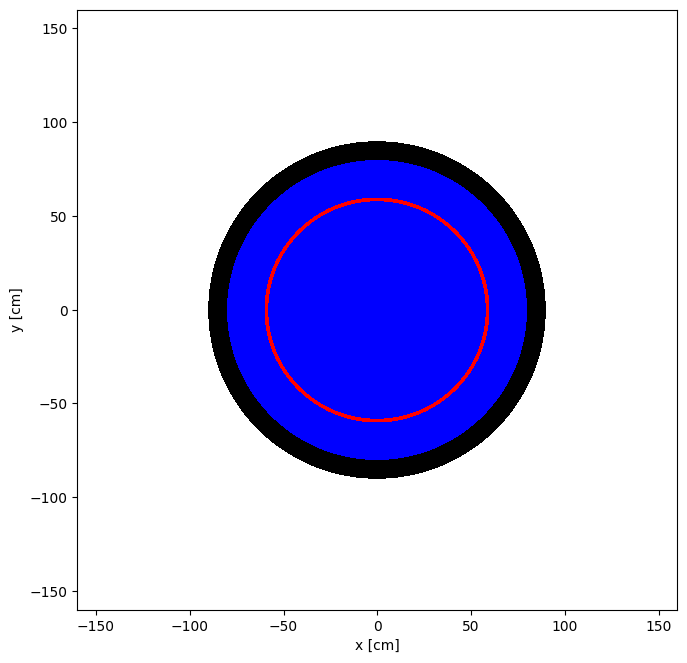

In [13]:
material_colors = {
    fuel_material: 'red',
    water: 'lightblue',
    heavy_water: 'blue',
    blanket_CA: 'black'
}

main_u.plot(
    width=(geom_size*4, geom_size*4),        # cm
    pixels=(600, 600),       # resolution
    basis='xy',              # plane (xy, xz, yz)
    color_by='material',     # color by material or cell
    colors = material_colors
)


In [17]:
# Load the statepoint file
sp = openmc.StatePoint('statepoint.100.h5')
print(sp)
print(sp.tallies.keys())

def plotCircle(ax ,r ,geom_size ,resolution, label=False):
    theta = np.linspace(0, 2*np.pi, 200)
    x = (r * np.cos(theta)+geom_size)*resolution/2
    y = (r * np.sin(theta)+geom_size)*resolution/2
    if label:
        ax.plot(x,y,'r--',alpha=0.2,label="edge of fuel shell")
    else:
        ax.plot(x,y,'r--',alpha=0.2)
    return (x,y)

tally = sp.get_tally(id=2)
print(tally)


flux = tally.get_slice(scores=['flux'])
fission = tally.get_slice(scores=['fission'])

flux.std_dev.shape = (geom_size*resolution_of_mesh, geom_size*resolution_of_mesh)
flux.mean.shape = (geom_size*resolution_of_mesh, geom_size*resolution_of_mesh)
fission.std_dev.shape = (geom_size*resolution_of_mesh, geom_size*resolution_of_mesh)
fission.mean.shape = (geom_size*resolution_of_mesh, geom_size*resolution_of_mesh)

#Setting up figures using gridspec
fig = plt.figure(figsize=(18,6))
gs = gridspec.GridSpec(1, 3, width_ratios=[1,1,1], wspace=0.4)



ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])
ax2 = fig.add_subplot(gs[2])

ax0.set_title("neutron flux\n [particle-cm/source particle]")
im0=ax0.imshow(flux.mean)
plotCircle(ax0, geom_ir, geom_size, resolution_of_mesh)
plotCircle(ax0, geom_or, geom_size, resolution_of_mesh, label=True)

ax0.set_xlabel('x [mm]')
ax0.set_ylabel('y [mm]')
fig.colorbar(im0, ax=ax0, fraction=0.046, pad=0.04)
ax0.legend(loc='lower left')

ax1.set_title("fission neutron production\n [particles produced/source particle]")
im1=ax1.imshow(fission.mean)
plotCircle(ax1, geom_ir, geom_size, resolution_of_mesh)
plotCircle(ax1, geom_or, geom_size, resolution_of_mesh, label=True)

ax1.set_xlabel('x [mm]')
ax1.set_ylabel('y [mm]')
fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
ax1.legend(loc='lower left')



# Create log-spaced energy bins from 1 keV to 10 MeV
energy_bins = np.logspace(3,7)

tally1=sp.get_tally(id=1)
#print(tally1.get_pandas_dataframe())

flux1 = tally1.get_pandas_dataframe()


ax2.plot(flux1['energy low [eV]'],flux1['mean'])

# Plot source energy PDF

ax2.set_xscale('log')  # log scale for x-axis
ax2.set_xlabel('Energy (eV)')
ax2.set_ylabel('Flux (particle-cm per source particle)')
ax2.set_title("Neutron energy in fuel")
#ax2.set_title("Neutron energy in moderator")
pos = ax0.get_position()  # returns [left, bottom, width, height]
pos2 = ax2.get_position()
# Set ax2 to have the same vertical position/height
ax2.set_position([pos2.x0, pos.y0, pos.width, pos.height])



dict_keys([np.int32(1), np.int32(2)])
Tally
	ID             =	2
	Name           =	
	Filters        =	MeshFilter
	Nuclides       =	total
	Scores         =	['flux', 'fission']
	Estimator      =	tracklength
	Multiply dens. =	True


ValueError: cannot reshape array of size 14400 into shape (580,580)

In [ ]:

#openmcRunDepletion()

In [ ]:
#Fra chatgpt
# Load depletion results
results = openmc.deplete.Results(filename="depletion_results.h5")

print(results.get_step_where(1.1574074074074073e-05)) #units days
results.export_to_materials(1,path="materials.xml")





In [ ]:
# Load materials from XML
#materials = openmc.Materials.from_xml("materials-finish.xml")

#Using fond materials 
materials = results.export_to_materials(1)
# Collect all nuclides present
nuclides = []

for mat in materials:
    for nuclide, amount,_ in mat.nuclides:
        nuclides.append([nuclide,amount])

print(nuclides)

In [ ]:
import openmc.data
import re
decay = openmc.data.Decay.from_endf("../endf-b-vii.1/decay/dec-094_Pu_239.endf")

def make_AZ_Str(AZ):
    #Makes sure that number has 3 digits as in endf files and turns the numbers into strings
    if AZ < 10:
        AZstr = f"00{AZ}"
    elif AZ < 100:
        AZstr = f"0{AZ}"
    else:
        AZstr = f"{AZ}"
    return AZstr

def has_alpha_decay(nuclide):
    #Checking if atoms have alpha decay
    nuclide_name=nuclide[0]
    Z, A, m =openmc.data.zam(nuclide_name)

    #Isolating the atomic symbol
    #print(nuclide_name)
    match = re.match(r"([A-Za-z]+)(\d+)(_)(m\d+)",nuclide_name)
    #print(match)
    m1=0
    if match == None:
        match = re.match(r"([A-Za-z]+)",nuclide_name)
        symbol =match.groups()[0]
    else:
        symbol, _,_ ,m1 =match.groups()

    #print(symbol,m1)
    Z = make_AZ_Str(Z)
    A = make_AZ_Str(A)
    #print(Z,symbol,A)
    try:
        if m1 != 0:
            dec = openmc.data.Decay.from_endf(f"../endf-b-vii.1/decay/dec-{Z}_{symbol}_{A}{m1}.endf")
        else:
            dec = openmc.data.Decay.from_endf(f"../endf-b-vii.1/decay/dec-{Z}_{symbol}_{A}.endf")
        for mode in dec.modes:
            if mode.modes[0] == "alpha":
                return True
        return False   
    except KeyError:
        print("Error")
        return False

#print(has_alpha_decay(nuclides[3]))        
alpha_nuclides = [nuc for nuc in nuclides if has_alpha_decay(nuc)]

print(alpha_nuclides)

In [ ]:
merged = defaultdict(float)

for name, value in alpha_nuclides:
    merged[name] += value

alpha_nuclides = [[name, val] for name, val in merged.items()]
print(alpha_nuclides)

In [ ]:
def alpha_decay_values(nuclide):
    #Returning possible alpha decay and branching ratios
    nuclide_name=nuclide[0]
    nuclide_amount=nuclide[1]
    Z, A, m =openmc.data.zam(nuclide_name)

    #Isolating the atomic symbol
    #print(nuclide_name)
    match = re.match(r"([A-Za-z]+)(\d+)(_)(m\d+)",nuclide_name)
    #print(match)
    m1=0
    if match == None:
        match = re.match(r"([A-Za-z]+)",nuclide_name)
        symbol =match.groups()[0]
    else:
        symbol, _,_ ,m1 =match.groups()

    #print(symbol,m1)
    Z = make_AZ_Str(Z)
    A = make_AZ_Str(A)
    #print(Z,symbol,A)
    if m1 != 0:
        dec = openmc.data.Decay.from_endf(f"../endf-b-vii.1/decay/dec-{Z}_{symbol}_{A}{m1}.endf")
    else:
        dec = openmc.data.Decay.from_endf(f"../endf-b-vii.1/decay/dec-{Z}_{symbol}_{A}.endf")
    try:
        decay_constant = dec.decay_constant.nominal_value #log(2)/half_life
    except ValueError as e:
        print(f"Skipping {dec.nuclide['name']} amount: {nuclide_amount:.3g}: {e}")
        decay_constant = 0
    if len(dec.spectra)!=0:
        alpha_data=dec.spectra['alpha']
        energies = [float(item['energy'].nominal_value) for item in alpha_data['discrete']] #can be continuous or discrete
        intensities  = [float(item['intensity'].nominal_value) for item in alpha_data['discrete']]
        

        activities = [decay_constant*nuclide_amount*intensity for intensity in intensities] #Calculation of activities
        if sum(activities)>1e-25:
            print(dec.nuclide['name'], f"amount:\t {nuclide_amount:.3g}, \tactivity of most intens line:\t {max(activities):.3g}")
            line, =plt.plot(energies, activities, "_", label=dec.nuclide['name'],ms=10)
            plt.vlines(energies,[0]*len(energies),activities,line.get_color(),alpha=0.3)
        elif sum(activities)>1e-35:
            print(dec.nuclide['name'], f"amount:\t {nuclide_amount:.3g}, \tactivity of most intens line:\t {max(activities):.3g}")
        return [nuclide_name,activities,energies]
    else:
        activity=decay_constant*nuclide_amount
        print(dec.nuclide['name'],"activity: ",f"{activity:.3g}"," has no spectra")
    return None


alpha_nucs_activity=[alpha_decay_values(nuc) for nuc in alpha_nuclides]

alpha_nucs_activity=[nuc for nuc in alpha_nucs_activity if nuc is not None]

plt.title("Alpha spectrum of material of the material with more than 1e-6 ao")
plt.semilogy()
plt.xlabel("energy (eV))")
plt.ylabel("activity (alpha/s)")

plt.legend()
print('\nArray of nuclide and the max activity')
for nuc in alpha_nucs_activity:
    print(nuc[0],max(nuc[1]))

In [ ]:
from pathlib import Path
path = Path("../endf-b-vii.1/decay/dec-000_Nn_001.endf")

print("Exists:", path.exists())
print("Absolute path:", path.resolve())